In [86]:
import pandas as pd
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)

In [87]:
from download import download_all

# select date range
START = "2026_04_10"
END  = "2026_04_10"

download_all(tables=["trains"], start_date=START, end_date=END)
download_all(tables=["stations"], start_date=START, end_date=END)
download_all(tables=['timetables'], start_date=START, end_date=END)
download_all(tables=['journeys'], start_date=START, end_date=END)

2026-04-12 01:20:43,737 [INFO] file_cache is only supported with oauth2client<4.0.0
2026-04-12 01:20:44,177 [INFO] [stations] already exists, overwriting with latest from Drive
2026-04-12 01:20:44,179 [INFO] [stations] downloading stations.parquet …
2026-04-12 01:20:44,896 [INFO] [stations] saved to /home/ntorquet/Documents/time-series/timeseries-analysis/PROJECT/EDA/../data/static/stations.parquet
2026-04-12 01:20:45,304 [INFO] [lines] already exists, overwriting with latest from Drive
2026-04-12 01:20:45,305 [INFO] [lines] downloading lines.parquet …
2026-04-12 01:20:46,090 [INFO] [lines] saved to /home/ntorquet/Documents/time-series/timeseries-analysis/PROJECT/EDA/../data/static/lines.parquet
2026-04-12 01:20:46,594 [INFO] [trains] found 28 file(s) in Drive
2026-04-12 01:20:46,597 [INFO] file_cache is only supported with oauth2client<4.0.0
2026-04-12 01:20:47,148 [INFO] [stations] already exists, overwriting with latest from Drive
2026-04-12 01:20:47,149 [INFO] [stations] downloadin

In [88]:
from loader import load_trains, load_timetables, load_journeys, load_weather

df_trains = load_trains(start_date=START, end_date=END)
print(f"Shape: {df_trains.shape}")
df_trains.head()

2026-04-12 01:20:55,916 [INFO] Loaded 173924 R1 train rows from 1 file(s)


Shape: (173924, 12)


,train_id,line_id,current_station_id,next_station_id,platform,status,delay_minutes,observations,timestamp,timestamp_minute,position_lat,position_lon
0,25602,R1,79412,79603,2,on_time,0,,2026-04-10 02:58:59,2026-04-10 02:58,41.560764,2.533921
1,25602,R1,78804,79603,2,on_time,0,,2026-04-10 02:58:59,2026-04-10 02:58,41.503155,2.423156
2,25602,R1,79408,79603,2,on_time,0,,2026-04-10 02:58:59,2026-04-10 02:58,41.546760,2.492575
3,25602,R1,79600,79603,2,on_time,0,,2026-04-10 02:58:59,2026-04-10 02:58,41.596008,2.607685
4,25602,R1,79009,79603,3,on_time,0,,2026-04-10 02:58:59,2026-04-10 02:58,41.512527,2.427627


In [89]:
df_timetables = load_timetables(start_date=START, end_date=END)
print(f"Shape: {df_timetables.shape}")
df_timetables.head()

2026-04-12 01:20:57,426 [INFO] Loaded 769738 R1 timetable rows from 1 file(s)


Shape: (769738, 12)


,train_id,station_id,planned_arrival,planned_departure,actual_arrival,actual_departure,platform,stop_type,observations,timestamp,stop_sequence,composition
0,25684,79406,2026-04-09 00:00:00,2026-04-08,2026-04-09 00:09:00,2026-04-08 00:09:00,2,C,,2026-04-08 20:17:39,NaN,None
1,77566,72301,2026-04-08 23:57:00,2026-04-08,2026-04-09 00:33:00,2026-04-08 00:36:00,1,C,,2026-04-08 21:20:13,NaN,None
2,77464,72210,2026-04-08 00:00:00,2026-04-08,2026-04-08 00:47:00,2026-04-08 00:47:00,4,C,,2026-04-08 21:20:13,NaN,None
3,77656,72302,2026-04-08 20:29:13,2026-04-08,2026-04-08 20:29:13,2026-04-08 00:00:00,2,C,,2026-04-08 20:10:13,5.0,true
4,25682,79410,2026-04-08 23:57:00,2026-04-08,2026-04-08 23:59:00,2026-04-08 00:02:00,2,C,,2026-04-08 19:58:53,NaN,None


In [90]:
df_journeys = load_journeys(start_date=START, end_date=END)
print(f"Shape: {df_journeys.shape}")
df_journeys.head()

2026-04-12 01:20:57,677 [INFO] Loaded 74941 R1 journey rows from 1 file(s)


Shape: (74941, 11)


,journey_id,train_id,origin_station_id,destination_station_id,departure_time,arrival_time,duration,accessible,steps,timestamp,duration_minutes
0,77768_72305_72209_2026-04-10 00:00:00,77768,72305,72209,2026-04-10 00:00:00,2026-04-10 00:33:00,0 days 00:33:00,False,1,2026-04-10 01:00:00,33.0
1,77768_72305_72300_2026-04-10 00:00:00,77768,72305,72300,2026-04-10 00:00:00,2026-04-10 00:17:00,0 days 00:17:00,False,1,2026-04-10 00:18:44,17.0
2,25795_79403_79407_2026-04-10 00:01:00,25795,79403,79407,2026-04-10 00:01:00,2026-04-10 00:11:00,0 days 00:10:00,True,1,2026-04-10 22:54:16,10.0
3,25693_79600_79608_2026-04-10 00:01:00,25693,79600,79608,2026-04-10 00:01:00,2026-04-10 00:22:00,0 days 00:21:00,True,1,2026-04-10 23:57:39,21.0
4,25472_71801_79009_2026-04-10 00:01:00,25472,71801,79009,2026-04-10 00:01:00,2026-04-10 00:09:00,0 days 00:08:00,True,1,2026-04-10 19:40:14,8.0


In [91]:
df_weather = load_weather(start_date=START, end_date=END)
print(f"Shape: {df_weather.shape}")
df_weather.head()

2026-04-12 01:20:57,690 [INFO] Loaded 37 weather rows from 1 file(s)


Shape: (37, 7)


,timestamp,timestamp_minute,temperature,precipitation,windspeed,weathercode,cloudcover
0,2026-04-10 00:30:59,2026-04-10 00:30,16.8,0.0,2.6,2,80
1,2026-04-10 00:40:12,2026-04-10 00:40,16.8,0.0,2.6,2,80
2,2026-04-10 01:00:25,2026-04-10 01:00,16.6,0.0,3.5,2,49
3,2026-04-10 01:20:43,2026-04-10 01:20,16.4,0.0,3.9,2,49
4,2026-04-10 02:00:40,2026-04-10 02:00,15.8,0.0,4.5,0,0


![alt text](img/r1_stations.gif "Title")

In [92]:
# first i want to match each station_id to the actual station name, and get the coordinates of each station
# this will allow me to visualize the data on a map, and also to get the distance between stations
unique_stations = pd.concat([df_timetables["station_id"], df_journeys["origin_station_id"], df_journeys["destination_station_id"]]).unique()
print(f"Number of unique stations: {len(unique_stations)}")
print(f"Unique station ids: {unique_stations}")

Number of unique stations: 39
Unique station ids: <StringArray>
['79406', '72301', '72210', '72302', '79410', '71801', '79403', '78804',
 '79408', '72305', '79500', '79409', '78805', '72211', '79601', '79600',
 '72209', '72303', '79502', '79605', '79412', '79407', '72300', '72205',
 '72204', '79009', '79606', '79603', '79405', '79404', '72207', '79608',
 '79200', '79501', '79604', '79602', '72208', '72206', '79607']
Length: 39, dtype: string


In [93]:
df_station_codes = pd.read_csv("station_codes.csv", dtype=str)
station_id_to_name = dict(zip(df_station_codes["CÓDIGO"], df_station_codes["DESCRIPCION"]))
df_r1_stations = df_station_codes[df_station_codes["CÓDIGO"].isin(unique_stations)][["CÓDIGO", "DESCRIPCION", "LATITUD", "LONGITUD"]].copy()
for station_id in unique_stations:
    if station_id not in station_id_to_name:
        print(f"Station id {station_id} not found in station codes") # yay! all found

# create dataframe with station_id, station_name, latitude, longitude, station_order
df_r1_stations.rename(columns={"CÓDIGO": "station_id", "DESCRIPCION": "station_name", "LATITUD": "latitude", "LONGITUD": "longitude"}, inplace=True)
df_r1_stations["station_order"] = ""
print(df_r1_stations["station_name"].unique())


['ARC DE TRIOMF' 'ARENYS DE MAR' 'BADALONA' 'BARCELONA-CLOT-ARAGO'
 'BARCELONA-SANTS' 'BLANES' 'CABRERA DE MAR-VILASSAR DE MAR'
 "CALDES D'ESTRAC" 'CALELLA' 'CANET DE MAR' 'CASTELLBISBAL' 'CORNELLA'
 'EL MASNOU' 'EL PAPIOL' 'GELIDA' 'LA GRANADA' 'LAVERN-SUBIRATS'
 "L'HOSPITALET DE LLOBREGAT" 'MAÇANET-MASSANES' 'MALGRAT DE MAR'
 'MARTORELL' 'MATARO' 'MOLINS DE REI' 'MONTGAT' 'MONTGAT-NORD' 'OCATA'
 'PINEDA DE MAR' 'PLAÇA  DE CATALUNYA' 'PREMIA DE MAR'
 'SANT ADRIA DE BESOS' 'SANT ANDREU DE LLAVANERES'
 'SANT FELIU DE LLOBREGAT' 'SANT JOAN DESPI' 'SANT POL DE MAR'
 "SANT SADURNI D'ANOIA" 'SANTA SUSANNA' 'TORDERA' 'VILAFRANCA DEL PENEDES'
 'VILASSAR DE MAR']


In [94]:
# MOLINS DE REI -> 0
# SANT FELIU DE LLOBREGAT -> 1
# SANT JOAN DESPI -> 2
# CORNELLA -> 3
# L'HOSPITALET DE LLOBREGAT -> 4
# BARCELONA-SANTS -> 5
# PLAÇA  DE CATALUNYA -> 6
# ARC DE TRIOMF -> 7
# BARCELONA-CLOT-ARAGO -> 8
# SANT ADRIA DE BESOS -> 9
# BADALONA -> 10
# MONTGAT -> 11
# MONTGAT-NORD -> 12
# EL MASNOU -> 13
# OCATA -> 14
# PREMIA DE MAR -> 15
# VILASSAR DE MAR -> 16
# CABRERA DE MAR-VILASSAR DE MAR -> 17
# MATARO -> 18
# SANT ANDREU DE LLAVANERES -> 19
# CALDES D'ESTRAC -> 20
# ARENYS DE MAR -> 21
# CANET DE MAR -> 22
# SANT POL DE MAR -> 23
# CALELLA -> 24
# PINEDA DE MAR -> 25
# SANTA SUSANNA -> 26
# MALGRAT DE MAR -> 27
# BLANES -> 28
# TORDERA -> 29
# MAÇANET-MASSANES -> 30
df_r1_stations["station_order"] = df_r1_stations["station_name"].map({
    "MOLINS DE REI": "0",
    "SANT FELIU DE LLOBREGAT": "1",
    "SANT JOAN DESPI": "2",
    "CORNELLA": "3",
    "L'HOSPITALET DE LLOBREGAT": "4",
    "BARCELONA-SANTS": "5",
    "PLAÇA  DE CATALUNYA": "6",
    "ARC DE TRIOMF": "7",
    "BARCELONA-CLOT-ARAGO": "8",
    "SANT ADRIA DE BESOS": "9",
    "BADALONA": "10",
    "MONTGAT": "11",
    "MONTGAT-NORD": "12",
    "EL MASNOU": "13",
    "OCATA": "14",
    "PREMIA DE MAR": "15",
    "VILASSAR DE MAR": "16",
    "CABRERA DE MAR-VILASSAR DE MAR": "17",
    "MATARO": "18",
    "SANT ANDREU DE LLAVANERES": "19",
    "CALDES D'ESTRAC": "20",
    "ARENYS DE MAR": "21",
    "CANET DE MAR": "22",
    "SANT POL DE MAR": "23",
    "CALELLA": "24",
    "PINEDA DE MAR": "25",
    "SANTA SUSANNA": "26",
    "MALGRAT DE MAR": "27",
    "BLANES": "28",
    "TORDERA": "29",
    "MAÇANET-MASSANES": "30"
})

df_r1_stations

,station_id,station_name,latitude,longitude,station_order
1,78804,ARC DE TRIOMF,41.3924353000000024849214241839945316314697265625,2.18041630000000008493543646181933581829071044...,7
2,79600,ARENYS DE MAR,41.5776846999999989407115208450704813003540039...,2.54920359999999979194740262755658477544784545...,21
3,79404,BADALONA,41.4458406999999979802851157728582620620727539...,2.24889070000000002025331014010589569807052612...,10
7,79009,BARCELONA-CLOT-ARAGO,41.409599200000002383603714406490325927734375,2.19052569999999979799554239434655755758285522...,8
11,71801,BARCELONA-SANTS,41.379334999999997535269358195364475250244140625,2.13947729999999980421421241771895438432693481...,5
13,79606,BLANES,41.6737575000000006752998160663992166519165039...,2.76904700000000003612399268604349344968795776...,28
15,79412,CABRERA DE MAR-VILASSAR DE MAR,41.5068640000000002032720658462494611740112304...,2.40134330000000018046080185740720480680465698...,17
17,79502,CALDES D'ESTRAC,41.5685223999999990951437212061136960983276367...,2.52715289999999992431867212872020900249481201...,20
18,79603,CALELLA,41.6147386999999966405994200613349676132202148...,2.66562140000000002970637069665826857089996337...,24
20,79601,CANET DE MAR,41.586560800000000881482264958322048187255859375,2.58110470000000002954720912384800612926483154...,22


In [95]:
# get only the rows where station_order is not empty
df_r1_stations = df_r1_stations[(df_r1_stations["station_order"] != "") & (df_r1_stations["station_order"].notna())].copy()

df_r1_stations["station_order"] = df_r1_stations["station_order"].astype(int)
df_r1_stations["latitude"] = df_r1_stations["latitude"].astype(float)
df_r1_stations["longitude"] = df_r1_stations["longitude"].astype(float)

df_r1_stations.sort_values("station_order", inplace=True)
df_r1_stations["latitude"] = df_r1_stations["latitude"].round(6)
df_r1_stations["longitude"] = df_r1_stations["longitude"].round(6)

df_r1_stations.reset_index(drop=True, inplace=True)
df_r1_stations.to_csv("r1_stations.csv", index=False)

In [96]:
for df in [df_trains, df_timetables, df_journeys, df_weather]:
    for col in df.columns:
        if "time" in col or "timestamp" in col:
            df[col] = pd.to_datetime(df[col], errors="coerce")

for col in ["current_station_id", "next_station_id"]:
    df_trains[col] = df_trains[col].astype(str)

df_timetables["station_id"] = df_timetables["station_id"].astype(str)
df_journeys["origin_station_id"] = df_journeys["origin_station_id"].astype(str)
df_journeys["destination_station_id"] = df_journeys["destination_station_id"].astype(str)

In [97]:
df_trains = df_trains.drop_duplicates(
    subset=["train_id", "timestamp", "current_station_id"]
)

df_trains = df_trains.sort_values(["train_id", "timestamp"])

In [98]:
df_trains["station_id"] = df_trains["current_station_id"].astype(str)

In [99]:
df_timetables["planned_arrival"] = pd.to_datetime(df_timetables["planned_arrival"])
df_timetables["actual_arrival"] = pd.to_datetime(df_timetables["actual_arrival"])

df_timetables["station_delay"] = (
    (df_timetables["actual_arrival"] - df_timetables["planned_arrival"])
    .dt.total_seconds() / 60
)

In [100]:
station_stats = df_timetables.groupby("station_id").agg({
    "station_delay": ["mean", "std", "count"]
}).reset_index()

station_stats.columns = ["station_id", "station_delay_mean", "station_delay_std", "station_count"]

In [101]:
df_trains = df_trains.merge(
    station_stats,
    left_on="current_station_id",
    right_on="station_id",
    how="left"
)

In [102]:
df_journeys["duration_minutes"] = pd.to_numeric(df_journeys["duration_minutes"], errors="coerce")

journey_stats = df_journeys.groupby(["origin_station_id", "destination_station_id"]).agg({
    "duration_minutes": ["mean", "std"]
}).reset_index()

journey_stats.columns = [
    "origin_station_id",
    "destination_station_id",
    "journey_mean_duration",
    "journey_std_duration"
]

In [103]:
df_trains = df_trains.merge(
    journey_stats,
    left_on=["current_station_id", "next_station_id"],
    right_on=["origin_station_id", "destination_station_id"],
    how="left"
)

In [104]:
df_weather = df_weather.sort_values("timestamp")

df_weather = df_weather.set_index("timestamp").resample("1min").ffill().reset_index()

In [ ]:
# ensure timestamp exists
df_trains["timestamp"] = pd.to_datetime(df_trains["timestamp"])

# create minute bucket
df_trains["timestamp_minute"] = df_trains["timestamp"].dt.floor("min")

# sort BOTH datasets (required for merge_asof)
df_trains = df_trains.sort_values("timestamp_minute")
df_weather = df_weather.sort_values("timestamp")

df_weather = df_weather.rename(columns={"timestamp": "weather_timestamp"})

# merge ONCE
df_trains = pd.merge_asof(
    df_trains.sort_values("timestamp_minute"),
    df_weather.sort_values("weather_timestamp"),
    left_on="timestamp_minute",
    right_on="weather_timestamp",
    direction="backward",
    tolerance=pd.Timedelta("30min")
)

print(df_trains.head())

  train_id line_id current_station_id next_station_id platform   status  \
0    25602      R1              79603           79603     None  on_time   
1    25602      R1              79412           79603        2  on_time   
2    25602      R1              79501           79603        2  on_time   
3    25602      R1              79408           79603        2  on_time   
4    25602      R1              79600           79603        2  on_time   

   delay_minutes observations           timestamp  timestamp_minute_x  \
0              0              2026-04-10 02:58:59 2026-04-10 02:58:00   
1              0              2026-04-10 02:58:59 2026-04-10 02:58:00   
2              0              2026-04-10 02:58:59 2026-04-10 02:58:00   
3              0              2026-04-10 02:58:59 2026-04-10 02:58:00   
4              0              2026-04-10 02:58:59 2026-04-10 02:58:00   

   position_lat  position_lon station_id_x station_id_y  station_delay_mean  \
0     41.614635      2.666053  

In [106]:
print(df_trains.columns)
df_trains["hour"] = df_trains["timestamp"].dt.hour
df_trains["day"] = df_trains["timestamp"].dt.day
df_trains["minute"] = df_trains["timestamp"].dt.minute
df_trains["is_peak"] = df_trains["hour"].between(7, 10) | df_trains["hour"].between(17, 20)

Index(['train_id', 'line_id', 'current_station_id', 'next_station_id',
       'platform', 'status', 'delay_minutes', 'observations', 'timestamp',
       'timestamp_minute_x', 'position_lat', 'position_lon', 'station_id_x',
       'station_id_y', 'station_delay_mean', 'station_delay_std',
       'station_count', 'origin_station_id', 'destination_station_id',
       'journey_mean_duration', 'journey_std_duration', 'weather_timestamp',
       'timestamp_minute_y', 'temperature', 'precipitation', 'windspeed',
       'weathercode', 'cloudcover'],
      dtype='object')


In [107]:
df_trains = df_trains.sort_values(["train_id", "timestamp"])

g = df_trains.groupby("train_id")["delay_minutes"]

df_trains["delay_lag_1"] = g.shift(1)
df_trains["delay_lag_5"] = g.shift(5)

df_trains["delay_roll_mean_10"] = g.transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())

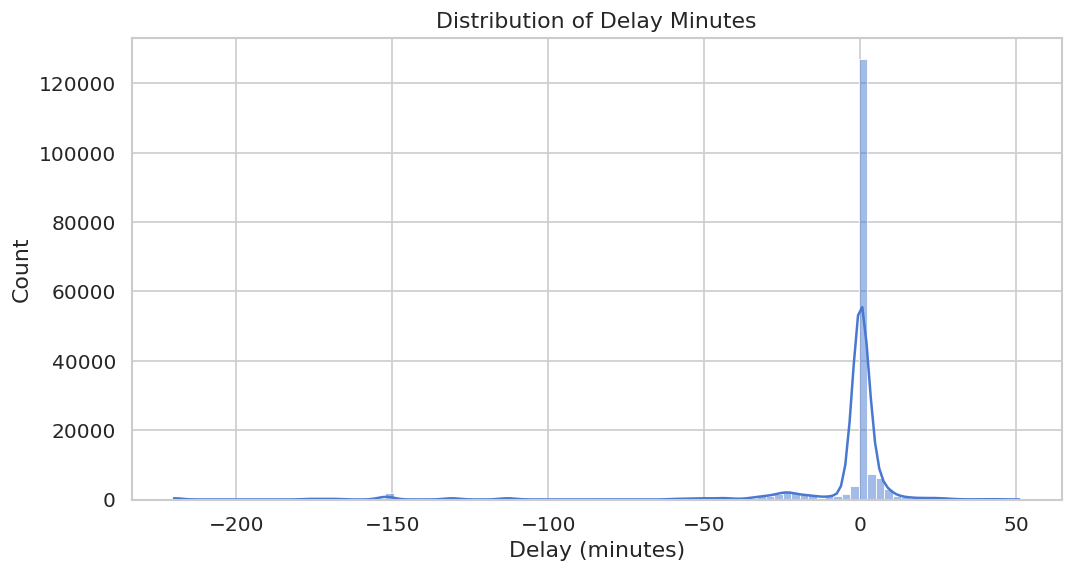

In [108]:
plt.figure(figsize=(10,5))
sns.histplot(df_trains["delay_minutes"], bins=100, kde=True)
plt.title("Distribution of Delay Minutes")
plt.xlabel("Delay (minutes)")
plt.show()

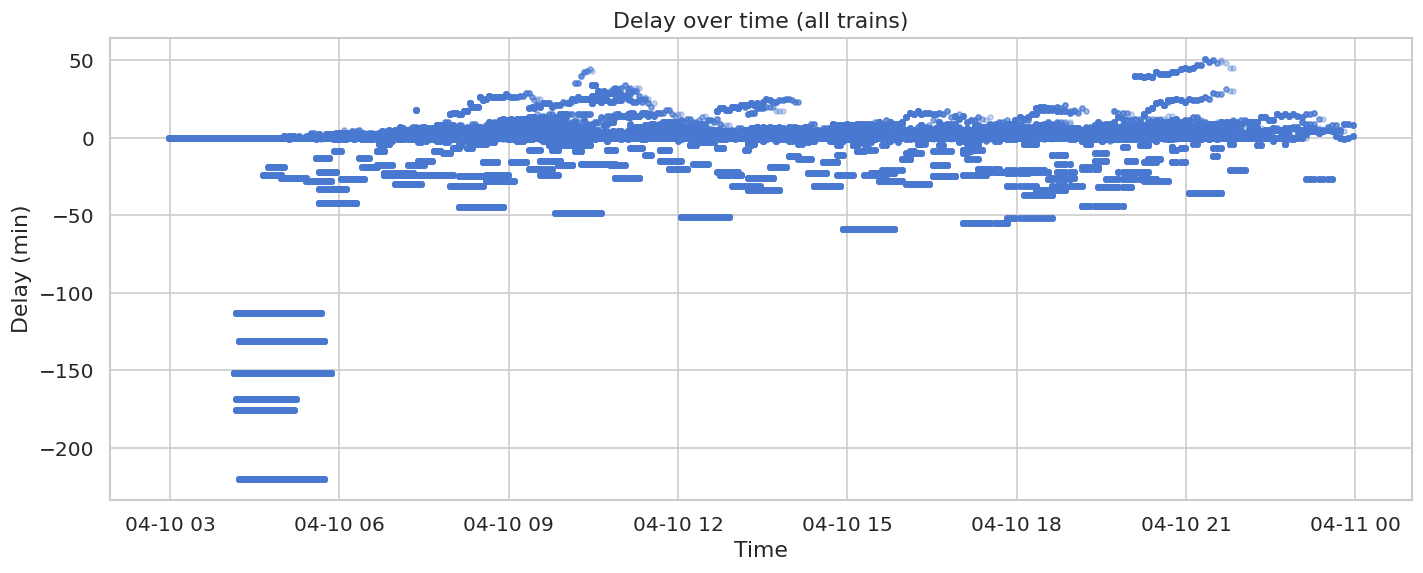

In [109]:
df_plot = df_trains.copy()
df_plot["timestamp"] = pd.to_datetime(df_plot["timestamp"])
df_plot = df_plot.sort_values("timestamp")

plt.figure(figsize=(14,5))
plt.plot(df_plot["timestamp"], df_plot["delay_minutes"], ".", alpha=0.3)
plt.title("Delay over time (all trains)")
plt.xlabel("Time")
plt.ylabel("Delay (min)")
plt.show()

2026-04-12 01:27:26,266 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-12 01:27:26,294 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


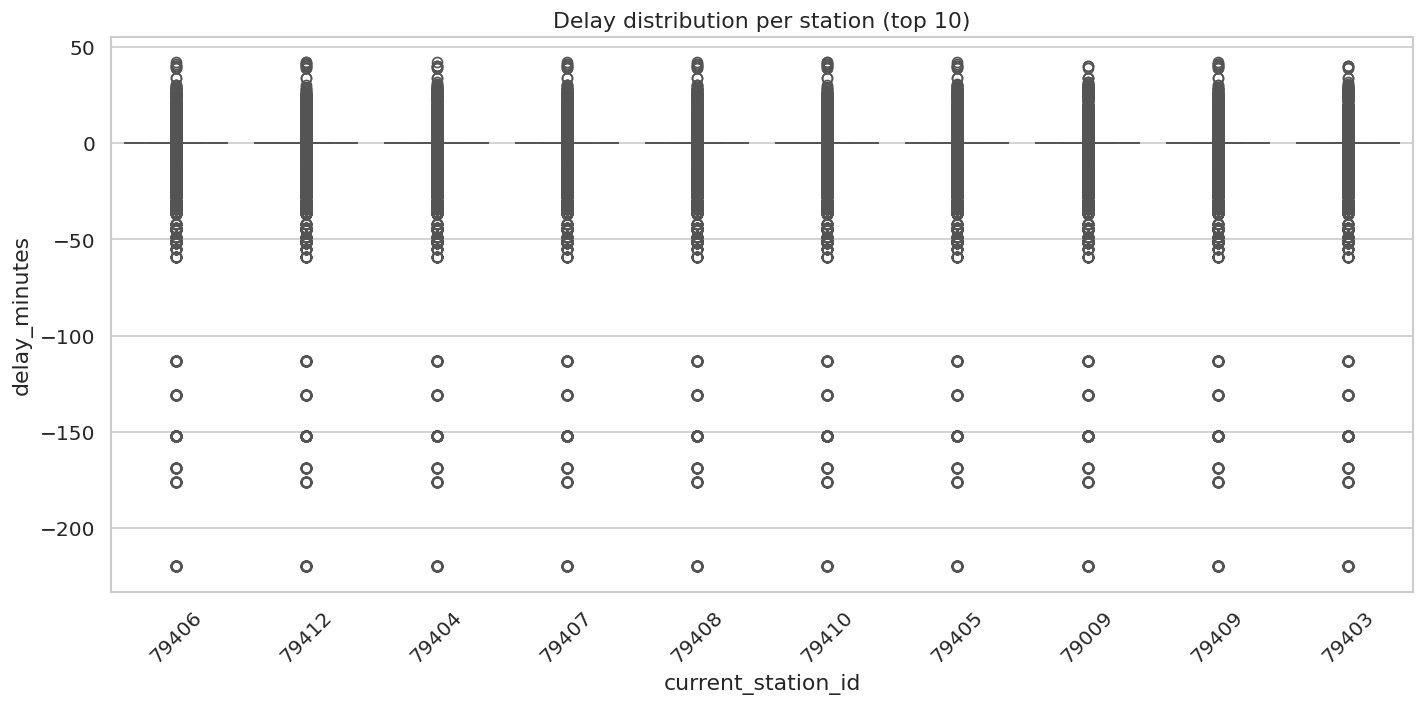

In [112]:
top_stations = df_trains["current_station_id"].value_counts().head(10).index
df_top = df_trains[df_trains["current_station_id"].isin(top_stations)]

plt.figure(figsize=(14,6))
sns.boxplot(data=df_top, x="current_station_id", y="delay_minutes")
plt.xticks(rotation=45)
plt.title("Delay distribution per station (top 10)")
plt.show()

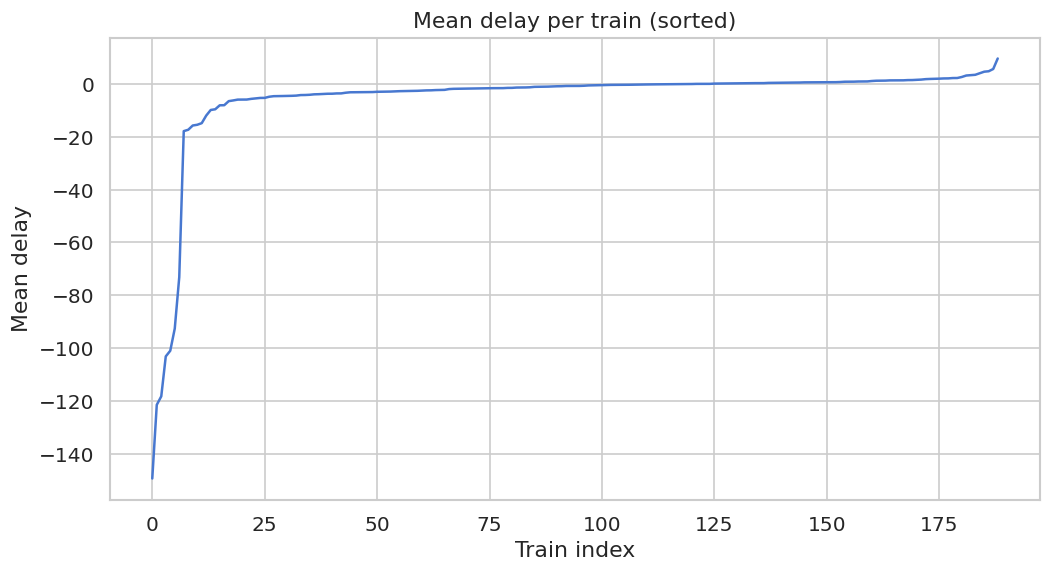

In [113]:
train_stats = df_trains.groupby("train_id")["delay_minutes"].mean().sort_values()

plt.figure(figsize=(10,5))
plt.plot(train_stats.values)
plt.title("Mean delay per train (sorted)")
plt.xlabel("Train index")
plt.ylabel("Mean delay")
plt.show()

2026-04-12 01:28:02,224 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-12 01:28:02,301 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


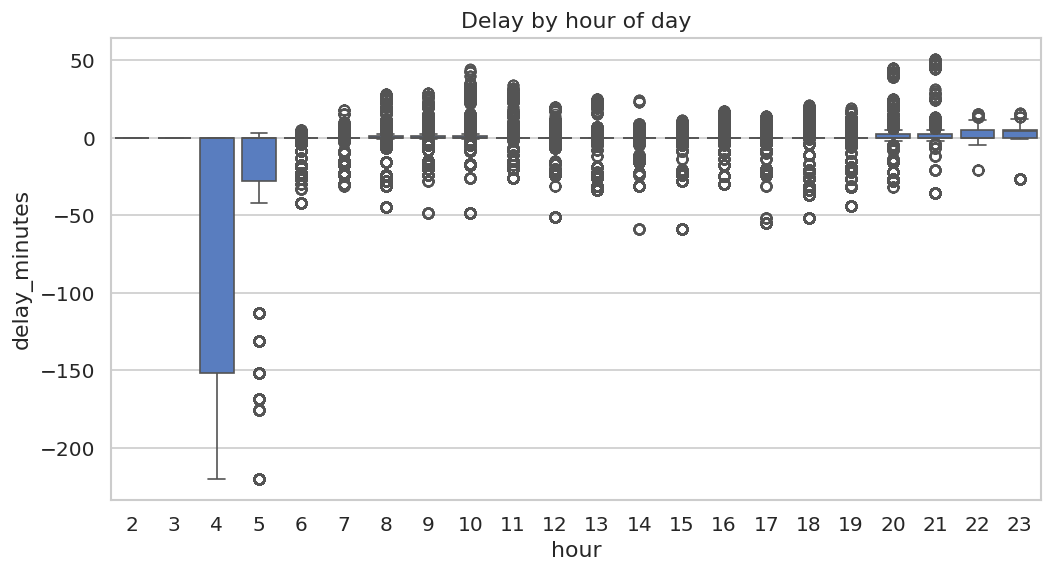

In [114]:
df_trains["hour"] = pd.to_datetime(df_trains["timestamp"]).dt.hour

plt.figure(figsize=(10,5))
sns.boxplot(x="hour", y="delay_minutes", data=df_trains)
plt.title("Delay by hour of day")
plt.show()

2026-04-12 01:28:18,325 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-12 01:28:18,377 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


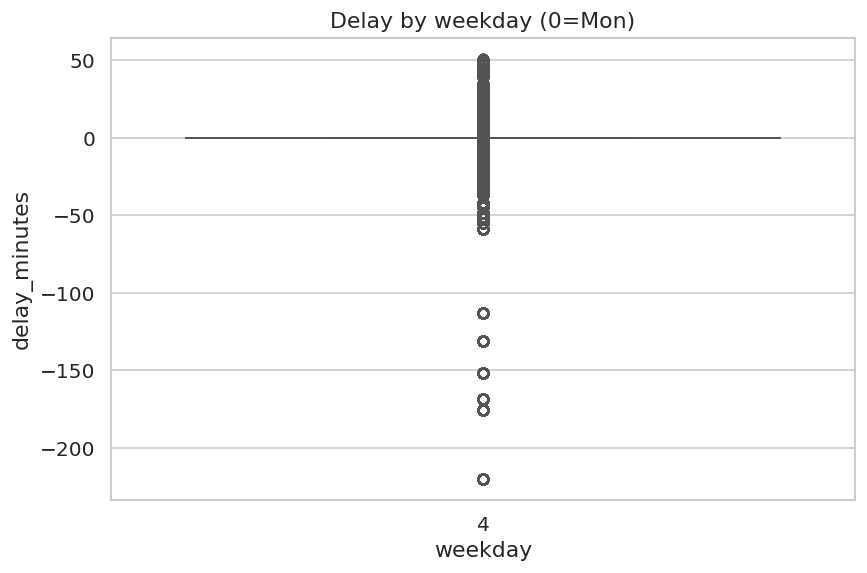

In [115]:
df_trains["weekday"] = pd.to_datetime(df_trains["timestamp"]).dt.weekday

plt.figure(figsize=(8,5))
sns.boxplot(x="weekday", y="delay_minutes", data=df_trains)
plt.title("Delay by weekday (0=Mon)")
plt.show()

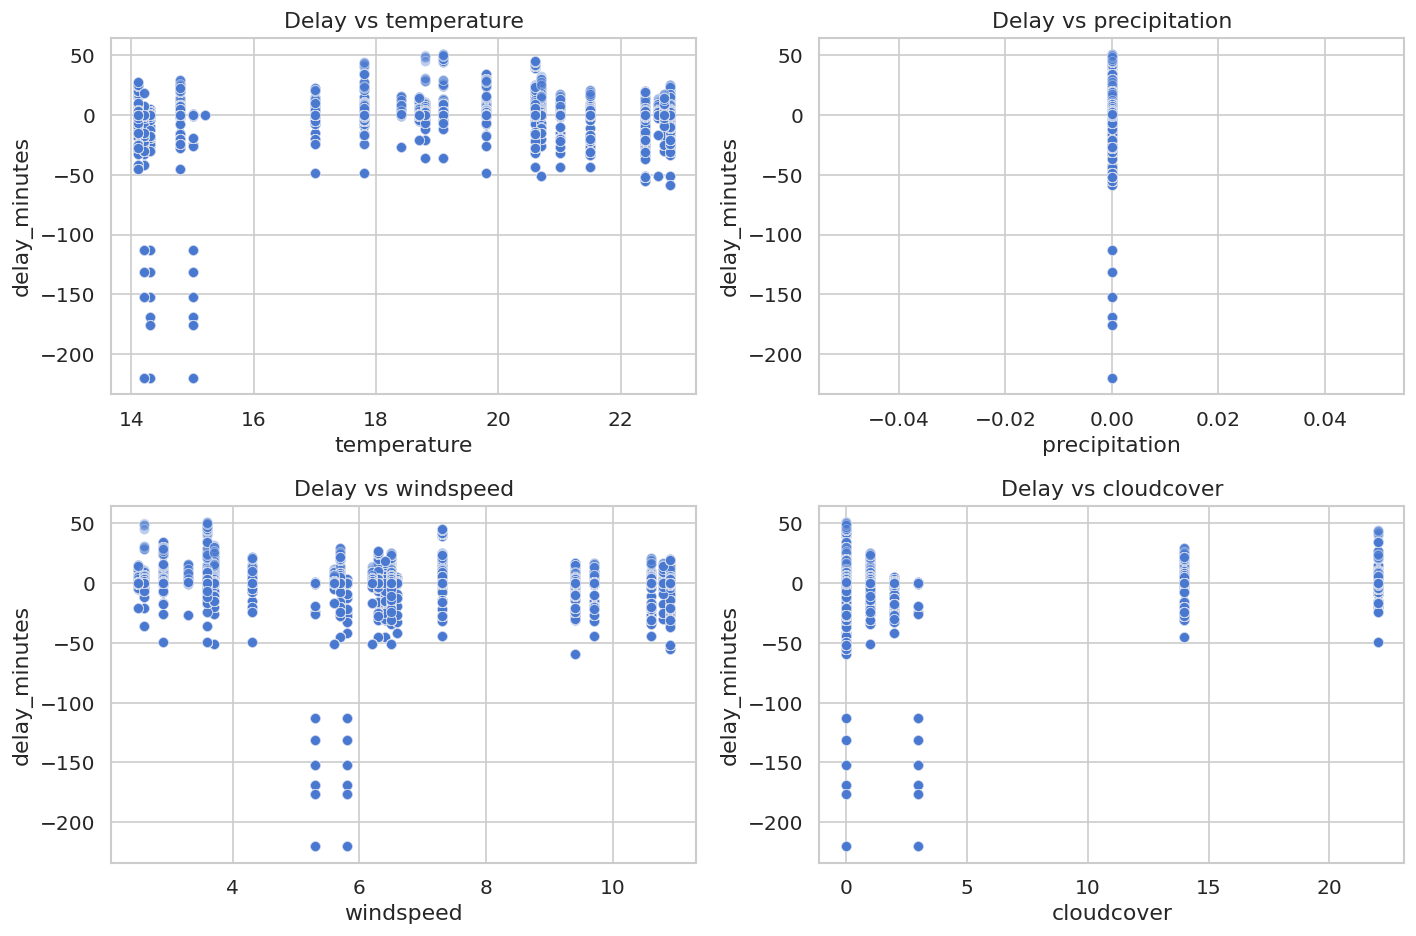

In [116]:
weather_cols = ["temperature", "precipitation", "windspeed", "cloudcover"]

plt.figure(figsize=(12,8))
for i, col in enumerate(weather_cols, 1):
    plt.subplot(2,2,i)
    sns.scatterplot(x=df_trains[col], y=df_trains["delay_minutes"], alpha=0.2)
    plt.title(f"Delay vs {col}")

plt.tight_layout()
plt.show()

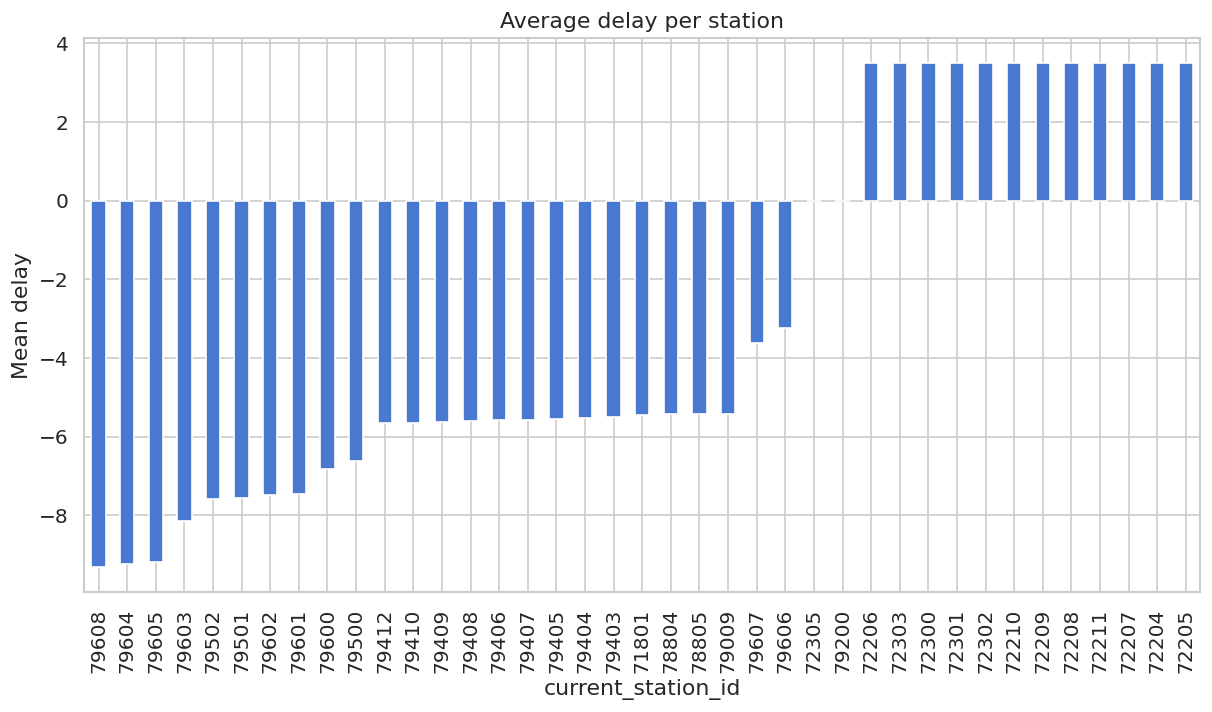

In [117]:
station_heat = df_trains.groupby("current_station_id")["delay_minutes"].mean().sort_values()

plt.figure(figsize=(12,6))
station_heat.plot(kind="bar")
plt.title("Average delay per station")
plt.ylabel("Mean delay")
plt.show()

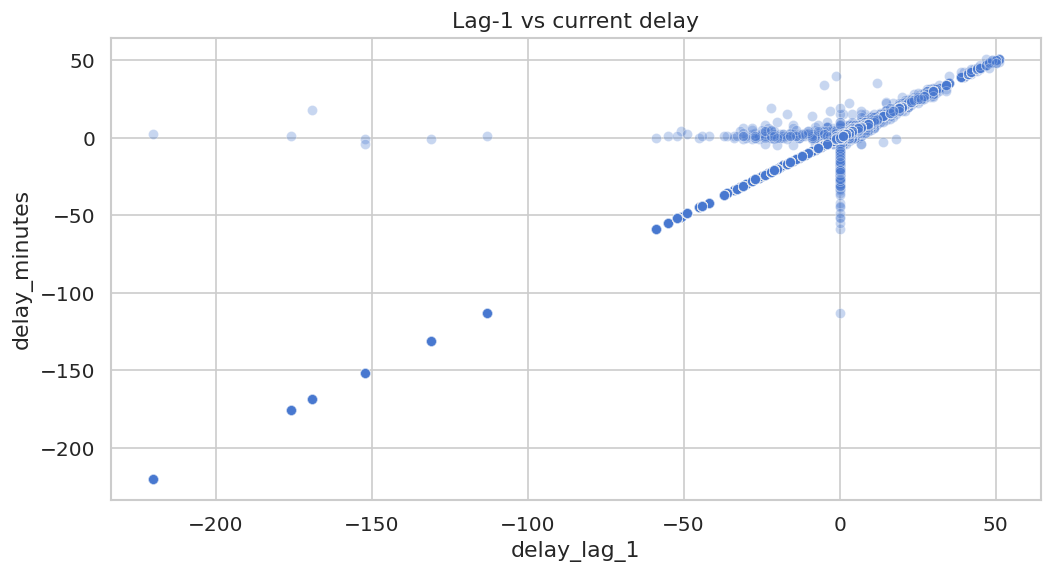

In [118]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=df_trains["delay_lag_1"],
    y=df_trains["delay_minutes"],
    alpha=0.3
)
plt.title("Lag-1 vs current delay")
plt.show()

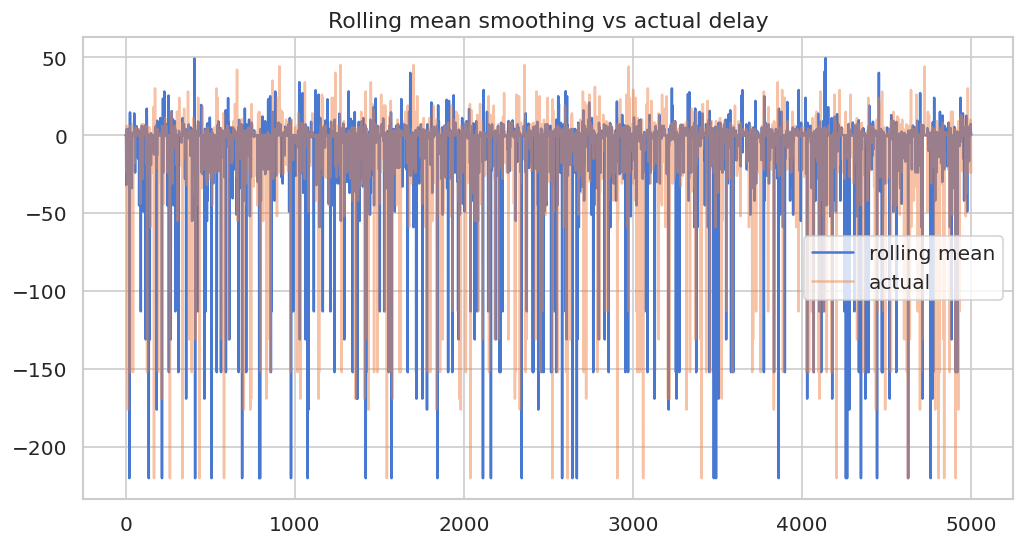

In [119]:
plt.figure(figsize=(10,5))
plt.plot(df_trains["delay_roll_mean_10"].sample(5000).values, label="rolling mean")
plt.plot(df_trains["delay_minutes"].sample(5000).values, alpha=0.5, label="actual")
plt.legend()
plt.title("Rolling mean smoothing vs actual delay")
plt.show()

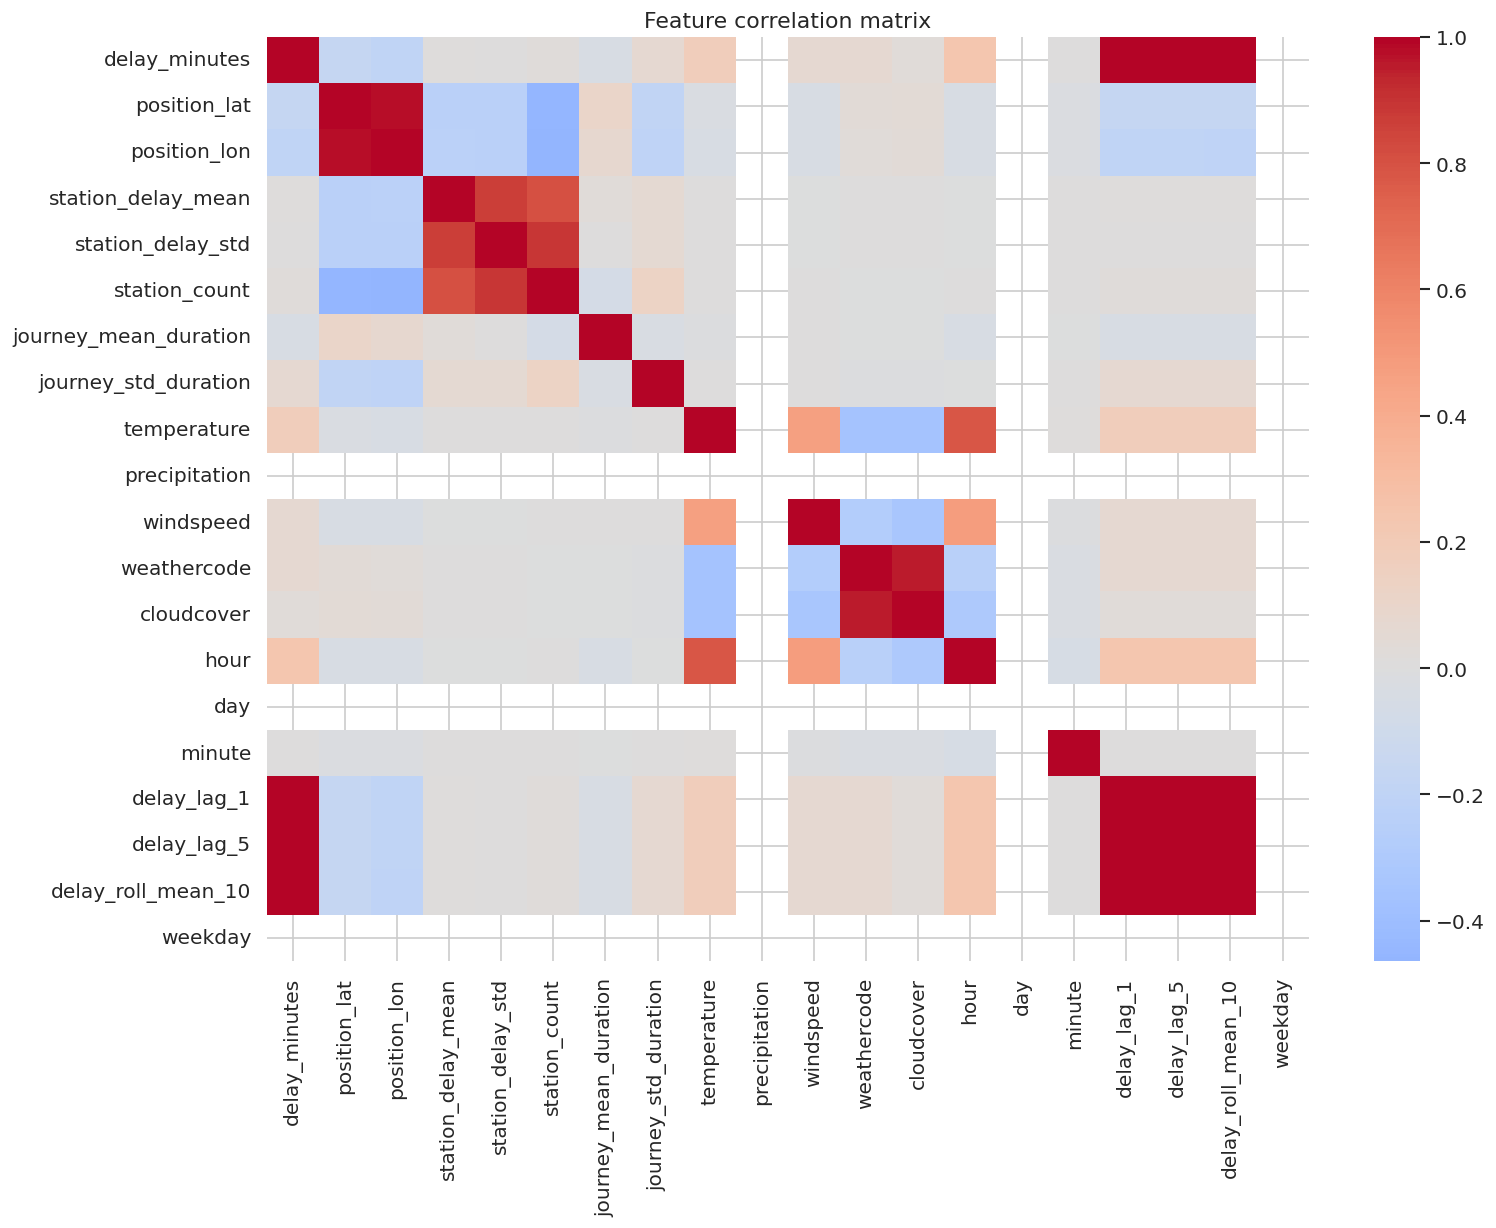

In [120]:
plt.figure(figsize=(14,10))
sns.heatmap(df_trains.select_dtypes("number").corr(), cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.show()